In [24]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep 
import os
import matplotlib.colors as mcolors

path = '/eos/user/m/mmarcheg/ml4reco/lightweight_transformers/data'

def list_full_dir(path):
    return [os.path.join(path, file) for file in os.listdir(path) if file.endswith('.root')]

files = [uproot.open(file) for file in list_full_dir(path)]

In [29]:
data, dataStr = {}, ("charge", "pdgId", "eta", "phi", "mass", "pt")

for file in files:
    events = file["Events;1"]

    for dataName in dataStr:
        arr = ak.ravel(events[f"GenPart_{dataName}"].array())
        
        if dataName in data:
            data[dataName] = ak.concatenate([data[dataName], arr])
        else: 
            data[dataName] = arr


for dataName in dataStr:
    print(dataName, len(data[dataName]))

charge 94000
pdgId 94000
eta 94000
phi 94000
mass 94000
pt 94000


In [30]:
# Histogram params

def labelPlot(ax):
    hep.cms.label("Phase 2 Simulation", ax=ax, loc=0, data=True, year=2026, rlabel='Sim Cluster', fontsize=22)

def defaultHist(ax, x):
    ax.hist(x, NUM_BINS, histtype='step', facecolor=mcolors.to_rgba('C0', alpha=0.8), edgecolor="black", hatch = "//\\\\", linewidth=1, fill=True)

def setLabel(ax, xlabel, ylabel):
    ax.set(xlabel = xlabel, ylabel = ylabel)

NUM_BINS = 100
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

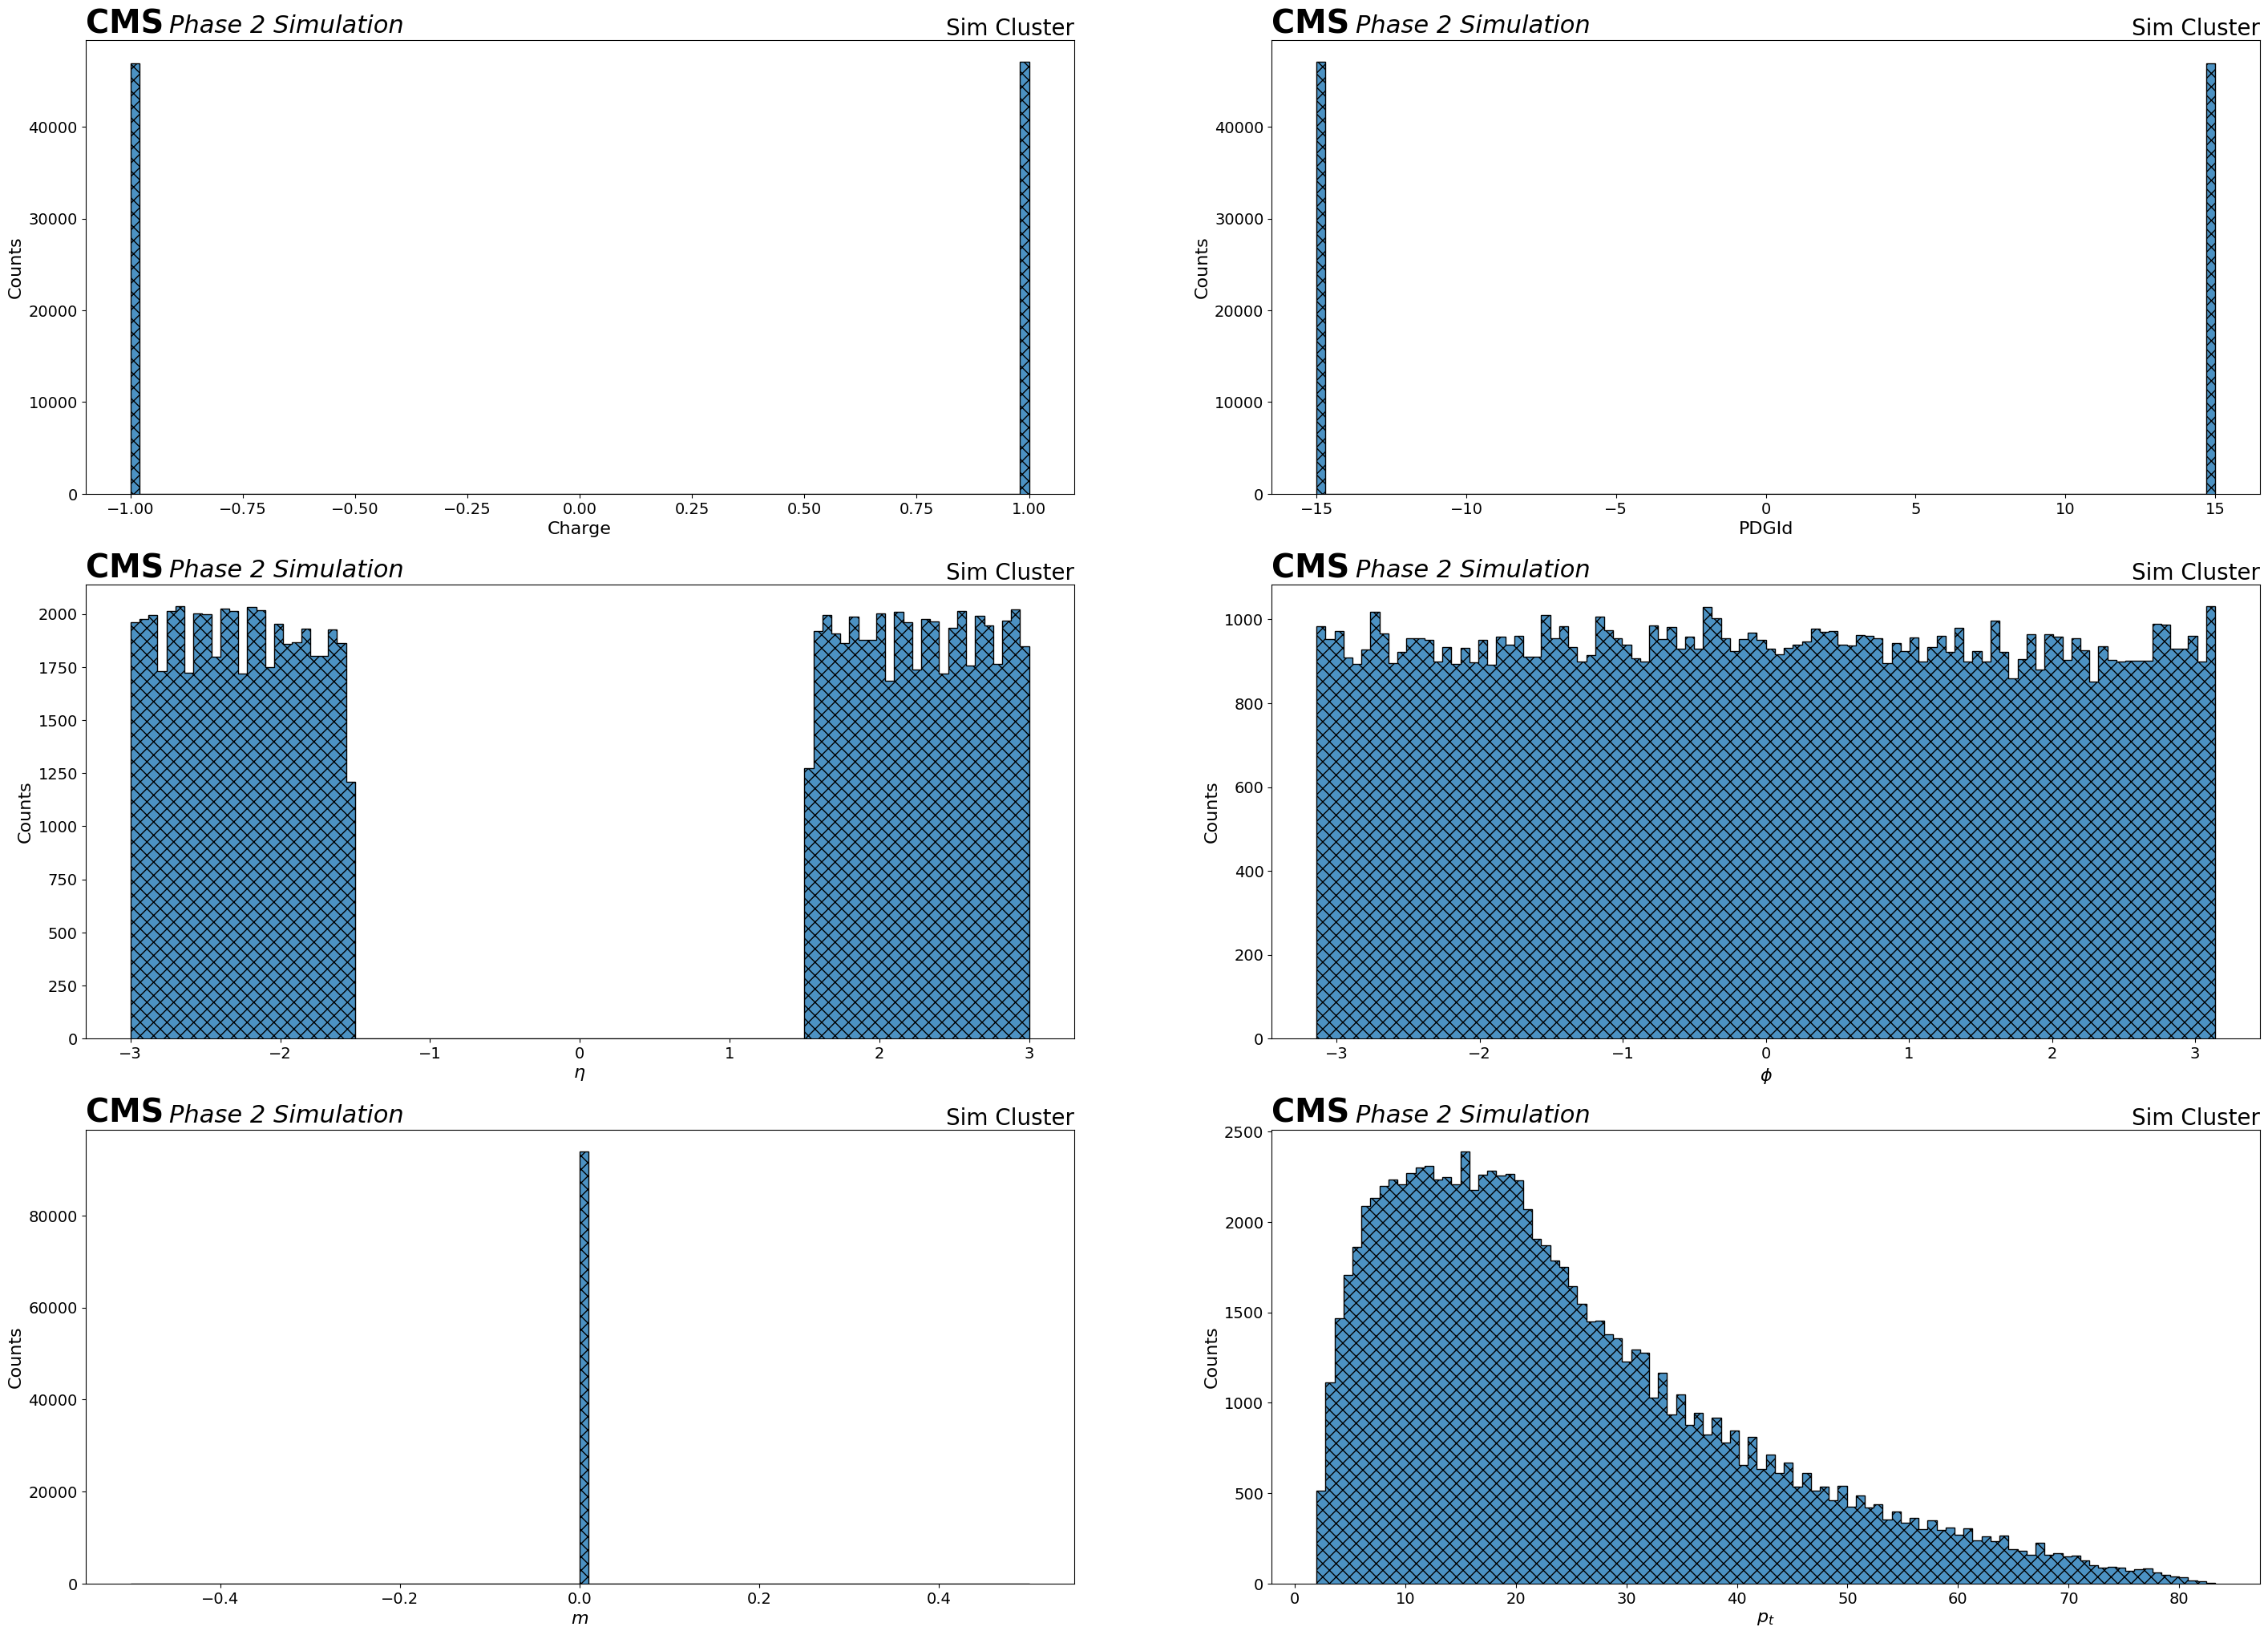

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(35,25))

((ax0, ax1), (ax2, ax3), (ax4, ax5)) = axes 

for ax, d, xlabel, ylabel in zip(axes.flatten(), data.values(), ('Charge', 'PDGId', r'$\eta$', r'$\phi$', r'$m$', r'$p_t$'), ['Counts'] * 6):
    labelPlot(ax)
    defaultHist(ax, d)
    setLabel(ax, xlabel, ylabel)

plt.show()
#plt.savefig('Output.jpg', dpi=300, bbox_inches='tight')